In [11]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveRegressor


In [13]:
data=pd.read_csv(r"C:\Users\Administrator\Desktop\krish_course\python_course\lec-9\Instagram data.csv",encoding="cp1252")
data

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Here’s how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
114,13700,5185,3041,5352,77,573,2,38,373,73,80,Here are some of the best data science certifi...,#datascience #datasciencejobs #datasciencetrai...
115,5731,1923,1368,2266,65,135,4,1,148,20,18,Clustering is a machine learning technique use...,#machinelearning #machinelearningalgorithms #d...
116,4139,1133,1538,1367,33,36,0,1,92,34,10,Clustering music genres is a task of grouping ...,#machinelearning #machinelearningalgorithms #d...
117,32695,11815,3147,17414,170,1095,2,75,549,148,214,Here are some of the best data science certifi...,#datascience #datasciencejobs #datasciencetrai...


In [14]:
data.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')

### Reach & Discovery
Impressions: Total number of times the post was seen.

From Home: Views from followers scrolling their main feed.

From Hashtags: Views from people clicking or following hashtags used.

From Explore: Views from the Instagram Explore page algorithm.

From Other: Views from shares (DMs), tags, or external links. 

### Engagement Metrics
Saves: Number of times users bookmarked the post.

Comments: Total number of text responses on the post.

Shares: How many times users sent the post to others.

Likes: Total number of "heart" reactions received. 
### Conversion & Content
Profile Visits: Times users clicked your username after seeing this post.

Follows: New followers gained directly because of this specific post.

Caption: The text description written by the author.

Hashtags: The specific # keywords included in the post. 

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.2+ KB


In [19]:
data.isnull().sum()
# data.isna().sum()

Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64

In [20]:
data.shape

(119, 13)

### Distribution of impressions received from home

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4260\3705032053.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['From Home'])


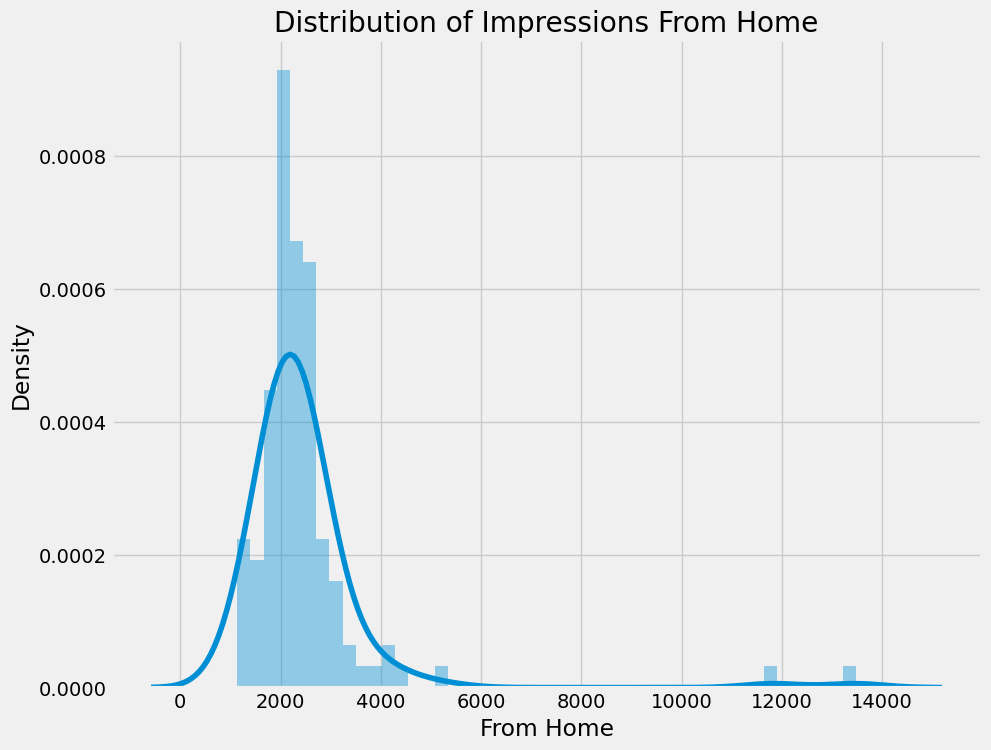

In [24]:
plt.figure(figsize=(10, 8))
plt.style.use('fivethirtyeight')
plt.title("Distribution of Impressions From Home")
sns.distplot(data['From Home'])
plt.show()


### The impressions I get from the home section on Instagram shows how much my posts reach my followers. Looking at the impressions from home, I can say it’s hard to reach all my followers daily. 

### Now let’s have a look at the distribution of the impressions I received from hashtags:


C:\Users\Administrator\AppData\Local\Temp\ipykernel_4260\3410305021.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['From Hashtags'])


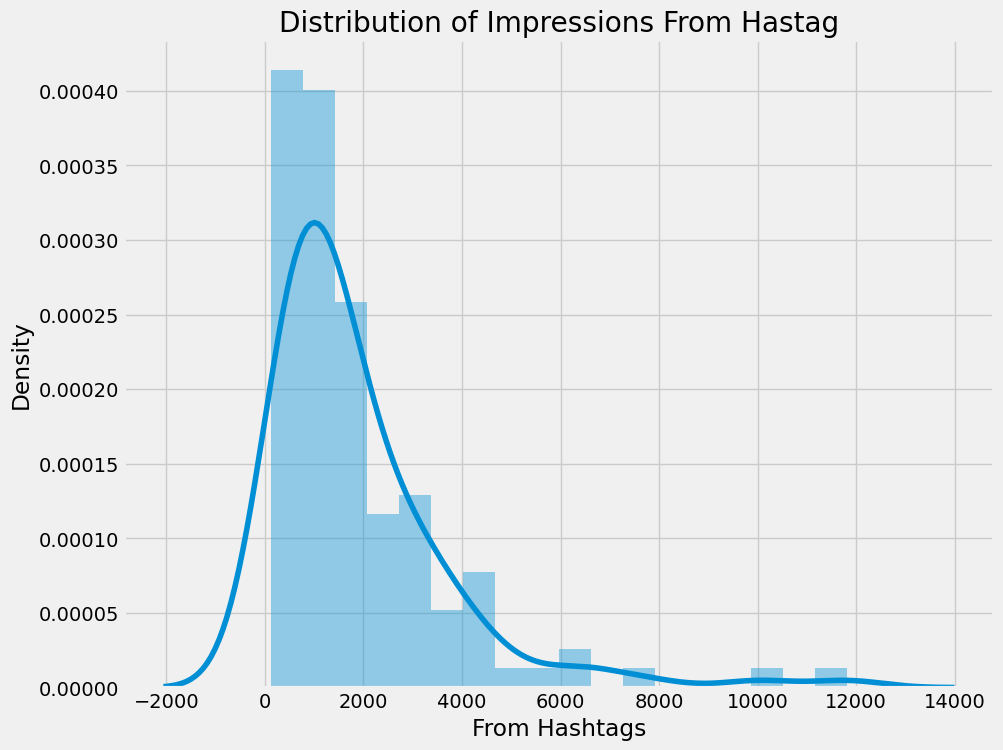

In [29]:
plt.figure(figsize=(10, 8))
plt.style.use('fivethirtyeight')
plt.title("Distribution of Impressions From Hastag")
sns.distplot(data['From Hashtags'])
plt.show()


## Hashtags are tools we use to categorize our posts on Instagram so that we can reach more people based on the kind of content we are creating. Looking at hashtag impressions shows that not all posts can be reached using hashtags, but many new users can be reached from hashtags.


##  Now let’s have a look at the distribution of impressions I have received from the explore section of Instagram:

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4260\3535978865.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['From Explore'])


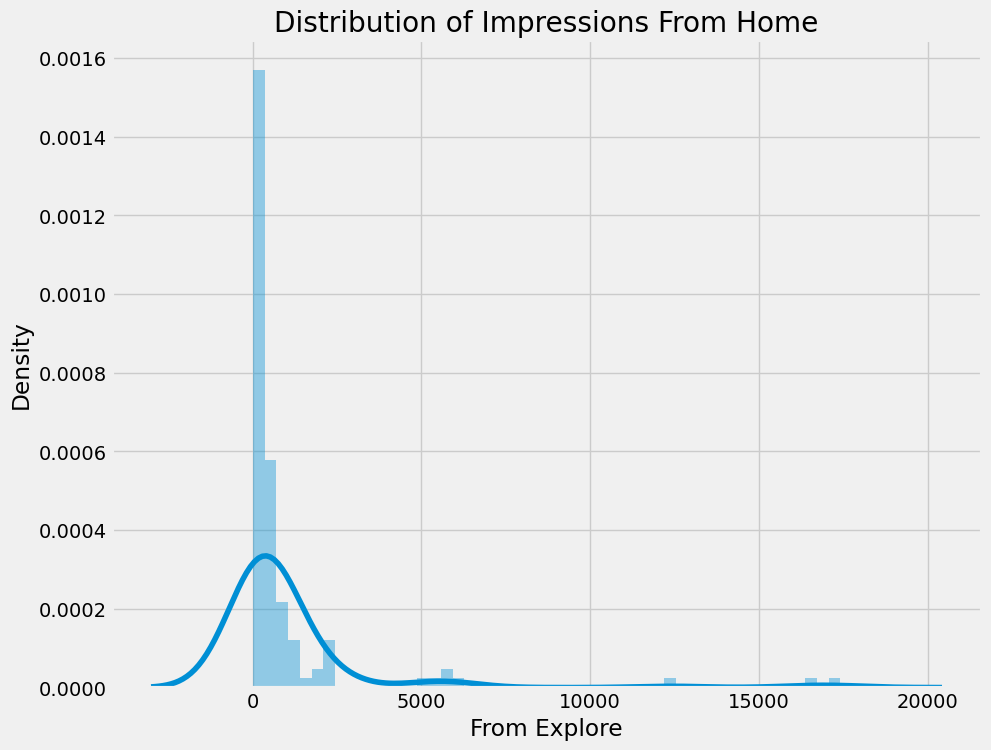

In [32]:
plt.figure(figsize=(10, 8))
plt.style.use('fivethirtyeight')
plt.title("Distribution of Impressions From Home")
sns.distplot(data['From Explore'])
plt.show()


## The explore section of Instagram is the recommendation system of Instagram. It recommends posts to the users based on their preferences and interests. By looking at the impressions I have received from the explore section, I can say that Instagram does not recommend our posts to users much. Some posts have received a good reach from the explore section, but it’s still very low compared to the reach I receive from hashtags.




## Now, let’s have a look at the percentage of impressions I get from various sources on Instagram:

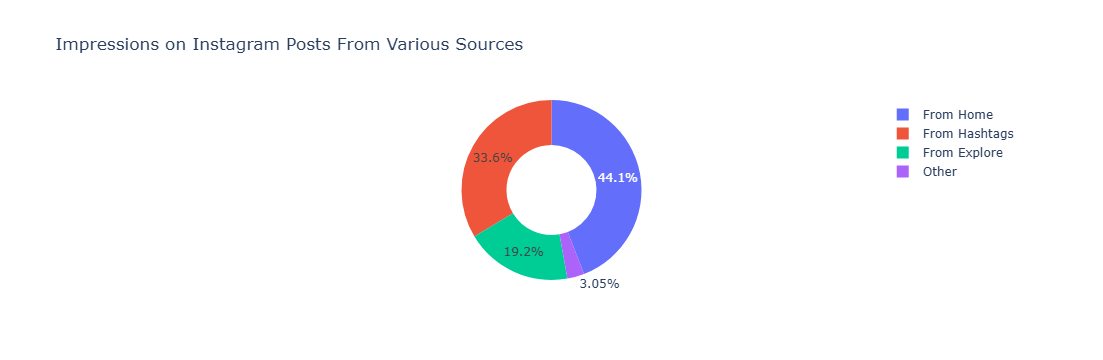

In [34]:
home = data["From Home"].sum()
hashtags = data["From Hashtags"].sum()
explore = data["From Explore"].sum()
other = data["From Other"].sum()

labels = ['From Home','From Hashtags','From Explore','Other']
values = [home, hashtags, explore, other]

fig = px.pie(data, values=values, names=labels, 
             title='Impressions on Instagram Posts From Various Sources', hole=0.5)
fig.show()


## So, the above donut plot shows that 44.1 percent of the reach is from my followers, 33.6 percent is from hashtags, 19.2 percent is from the explore section, and 3.05 percent is from other sources.

## Now, let’s analyze the content of my Instagram posts. The dataset has two columns, caption and hashtags, which will help us understand the content I post on Instagram.

## Let’s create a word cloud of the caption column to look at the most used words in the caption of my Instagram posts:


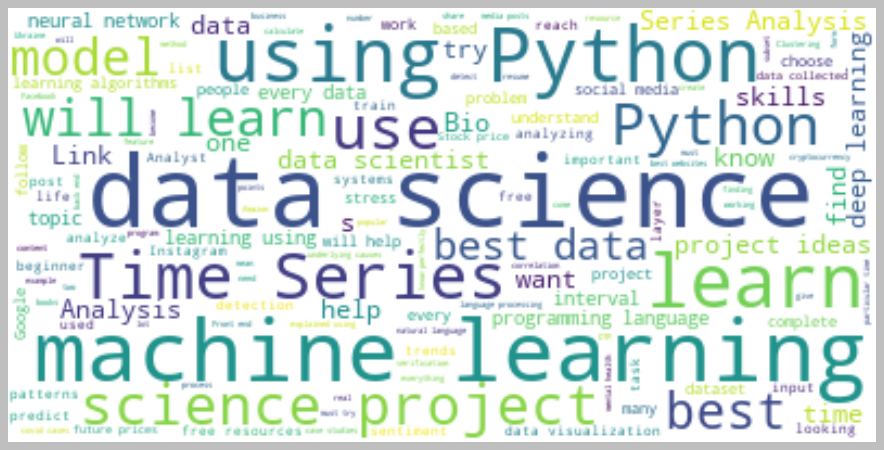

In [45]:
text = " ".join(i for i in data.Caption)
stopwords = set(STOPWORDS)
wordcloud = WordCloud(stopwords=stopwords, background_color="white").generate(text)
plt.style.use('classic')
plt.figure( figsize=(14,12))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


### In our Data Content have Mostly Depends on Words like Data Science and Machine Learning and Using Python and Learn.
### From that we can say that it follows content like Data Science and Machine Learning in every Post
## the words (using,python,data science,machine learning) has the highest frequency and importance of words within a text dataset

## The content mainly focuses on Data Science and Machine Learning, frequently using Python and learning-related topics. This shows a consistent theme across most posts.

## Now, let’s analyze relationships to find the most important factors of our Instagram reach. It will also help us in understanding how the Instagram algorithm works.

Let’s have a look at the relationship between the number of likes and the number of impressions on my Instagram posts:


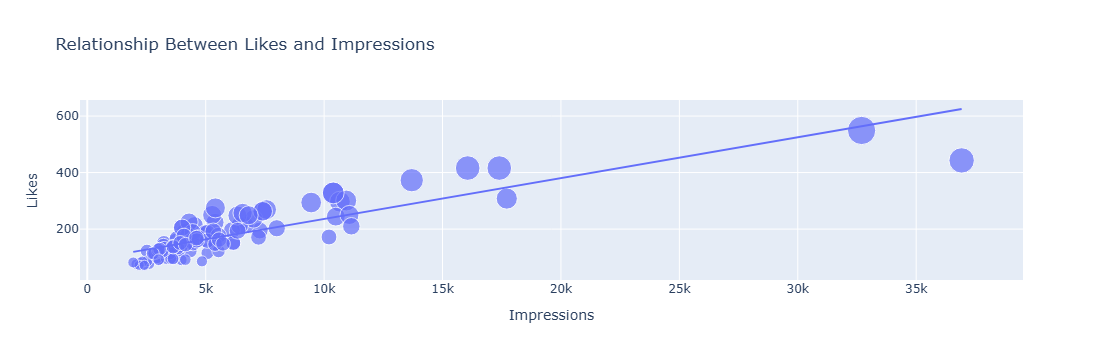

In [49]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Likes", size="Likes", trendline="ols", 
                    title = "Relationship Between Likes and Impressions")
figure.show()


## There is a linear relationship between the number of likes and the reach I got on Instagram. 


## Now let’s see the relationship between the number of comments and the number of impressions on my Instagram posts:

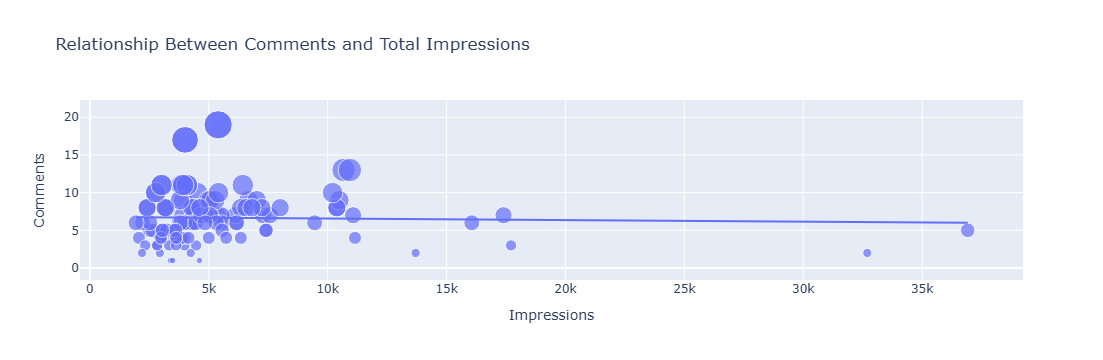

In [50]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Comments", size="Comments", trendline="ols", 
                    title = "Relationship Between Comments and Total Impressions")
figure.show()


## It looks like the number of comments we get on a post doesn’t affect its reach. 


### Now, let’s have a look at the relationship between the number of shares and the number of impressions:

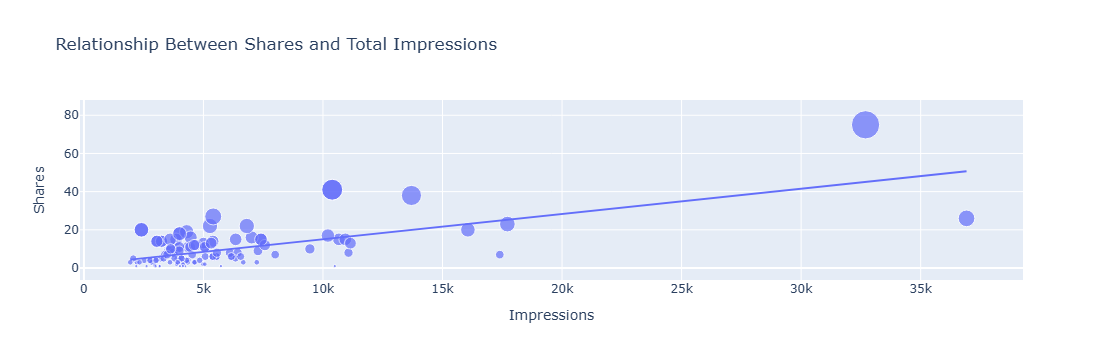

In [53]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Shares", size="Shares", trendline="ols", 
                    title = "Relationship Between Shares and Total Impressions")
figure.show()


## A larger number of shares will result in a higher reach, but shares don’t affect the reach of a post as much as likes do.

##  Now let’s have a look at the relationship between the number of saves and the number of impressions:


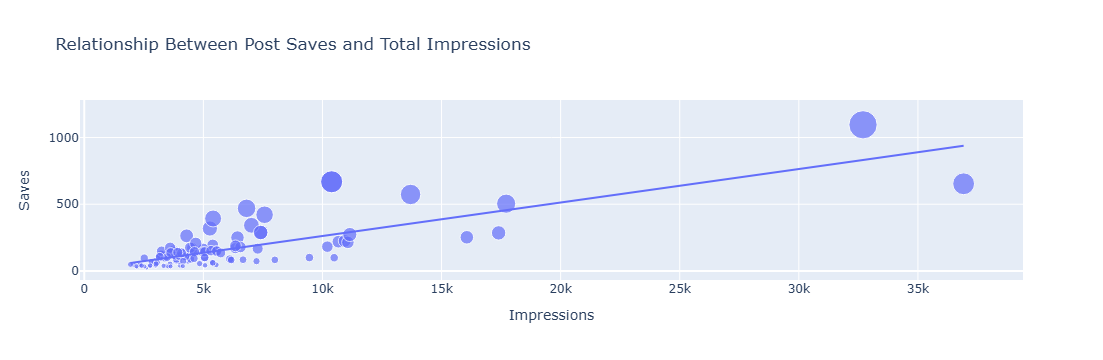

In [54]:
figure = px.scatter(data_frame = data, x="Impressions",
                    y="Saves", size="Saves", trendline="ols", 
                    title = "Relationship Between Post Saves and Total Impressions")
figure.show()


## There is a linear relationship between the number of times my post is saved and the reach of my Instagram post. 

## Now let’s have a look at the correlation of all the columns with the Impressions column:

Impressions       1.000000
From Explore      0.893607
Follows           0.889363
Likes             0.849835
From Home         0.844698
Saves             0.779231
Profile Visits    0.760981
Shares            0.634675
From Other        0.592960
From Hashtags     0.560760
Comments         -0.028524
Name: Impressions, dtype: float64


<Axes: >

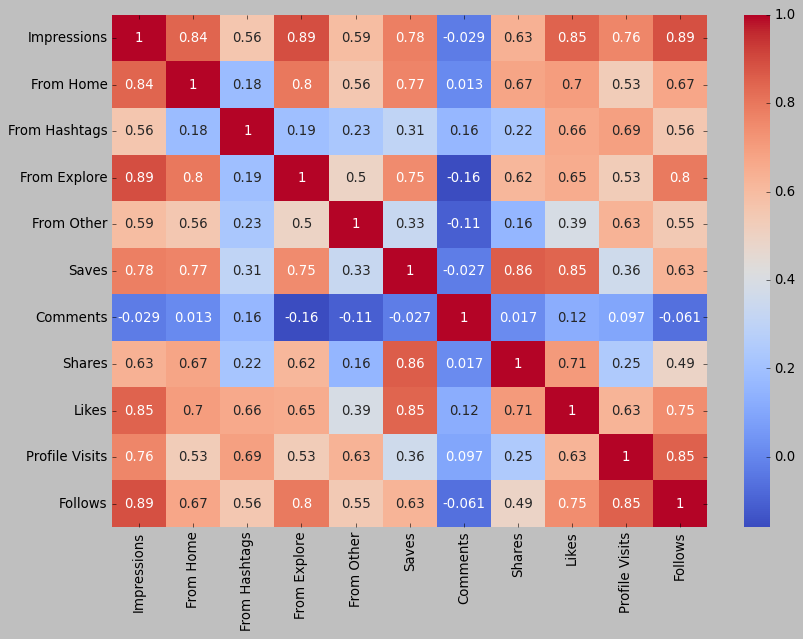

In [65]:
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(12,8))
print(correlation["Impressions"].sort_values(ascending=False))
# Convert the series to a 1D DataFrame for the heatmap
#sns.heatmap(correlation[["Impressions"]].sort_values(by="Impressions", ascending=False), annot=True)
sns.heatmap(correlation, annot=True, cmap="coolwarm")

## So, we can say that more likes and saves will help you get more reach on Instagram. A higher number of shares will also help you get more reach, but a low number will not affect your reach.




## Analyzing Conversion Rate
In Instagram, conversation rate means how many followers you get from a post’s profile visits. The formula that you can use to calculate the conversion rate is (Follows/Profile Visits) * 100. Now, let’s have a look at the conversation rate of my Instagram account:

In [67]:
conversion_rate = (data["Follows"].sum() / data["Profile Visits"].sum()) * 100
print(round(conversion_rate,2))


41.0


## So, the conversation rate of my Instagram account is 31%, which sounds like a very good conversation rate.

##  Let’s have a look at the relationship between the total profile visits and the number of followers gained from all profile visits:

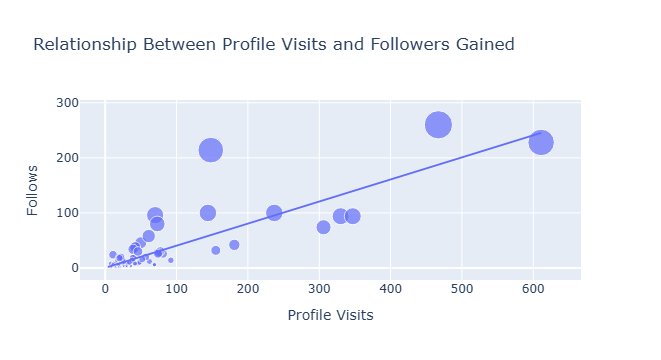

In [68]:
figure = px.scatter(data_frame = data, x="Profile Visits",
                    y="Follows", size="Follows", trendline="ols", 
                    title = "Relationship Between Profile Visits and Followers Gained")
figure.show()


## The relationship between profile visits and followers gained is also linear.




## Instagram Reach Prediction Model
Now, in this section, I will train a machine learning model to predict the reach of an Instagram post. Let’s split the data into training and test sets before training the model:

In [69]:
x = np.array(data[['Likes', 'Saves', 'Comments', 'Shares', 
                   'Profile Visits', 'Follows']])
y = np.array(data["Impressions"])
xtrain, xtest, ytrain, ytest = train_test_split(x, y, 
                                                test_size=0.2, 
                                                random_state=42)


In [70]:
#Now here’s is how we can train a machine learning model to predict the reach of an Instagram post using Python:

model = PassiveAggressiveRegressor()
model.fit(xtrain, ytrain)
model.score(xtest, ytest)


0.8629244367245741

In [74]:
# Now let’s predict the reach of an Instagram post by giving inputs to the machine learning model:
# Features = [['Likes','Saves', 'Comments', 'Shares', 'Profile Visits', 'Follows']]
features = np.array([[282.0, 233.0, 4.0, 9.0, 165.0, 54.0]])
model.predict(features)


array([12247.81232707])

## So, this is how you can analyze and predict the reach of Instagram posts with machine learning using Python. If a content creator wants to do well on Instagram in the long run, they must look at the data of their Instagram reach. That is where the use of Data Science in social media comes in.
